In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!pip install -q transformers datasets accelerate scikit-learn pandas "numpy<2.3.0" matplotlib seaborn

In [3]:

import pandas as pd
import numpy as np
import re
import pickle
import torch
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import warnings
from IPython.display import display

"""Tắt cảnh báo rác trên màn hình"""
warnings.filterwarnings('ignore')

In [4]:

DATA_PATH = '/content/drive/MyDrive/CleanDatav2/datasets/HQ-2025.csv'
MODEL_SAVE_PATH = '/content/drive/MyDrive/CleanDatav2/working'
CHECKPOINT_PATH = '/content/drive/MyDrive/CleanDatav2/working/model/checkpoints'

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print("Đang đọc dữ liệu Input...")
try:
    df_train = pd.read_csv(DATA_PATH, encoding='utf-8', on_bad_lines='skip', low_memory=False, dtype=str)
except:
    df_train = pd.read_csv(DATA_PATH, encoding='latin1', on_bad_lines='skip', low_memory=False, dtype=str)

"""Loại bỏ các dòng không có tên hàng"""
df_train = df_train.dropna(subset=['Tên hàng'])
print(f"Số dòng dữ liệu ban đầu: {len(df_train)}")

"""Hiển thị dữ liệu trực quan"""
display(df_train.head())

Đang đọc dữ liệu Input...
Số dòng dữ liệu ban đầu: 310294


,Ngày,Mã HS,Công ty NK,Tên hàng,DVT,Lượng,Giá trị,Đơn giá,Unnamed: 8,Hãng,...,Quốc gia,Châu lục,MDSD,Công ty XK,Incoterms,Method_of_Payment,Công suất.1,Loại 1,Loại 2,Năm
0,Tháng 1,94056190,CôNG TY TNHH OHSUNG VINA THáI BìNH,#&Biển hiệu công ty được chiếu sáng bằng đèn l...,Pieces,1,2828,"2828,01",NaN,NaN,...,Vietnam (VN),Asia,NaN,CONG TY TNHH XAY DUNG MIRAE,DAP,KC,NaN,NaN,NaN,NaN
1,Tháng 1,94054990,CôNG TY TNHH DONGKWANG,"#&Bóng đèn 600x600 48W,hàng mới 100%",Pieces,10,209,"20,9",NaN,NaN,...,Vietnam (VN),Asia,NaN,CONG TY TNHH DN 365,DAP,KC,NaN,NaN,NaN,NaN
2,Tháng 1,85395290,CôNG TY TNHH OGK HANOI,"#&Bóng đèn led 60cm, là loại bóng đèn tuýp led...",Pieces,129,552,"4,28",NaN,NaN,...,Vietnam (VN),Asia,NaN,CONG TY TNHH MOT THANH VIEN HA MINH TRUONG,DAP,KC,NaN,NaN,NaN,NaN
3,Tháng 1,85395290,CôNG TY TNHH OGK HANOI,"#&Bóng đèn led Rạng Đông 20W, là loại bóng đèn...",Pieces,527,743,"1,41",NaN,NaN,...,Vietnam (VN),Asia,NaN,CONG TY TNHH MOT THANH VIEN HA MINH TRUONG,DAP,KC,NaN,NaN,NaN,NaN
4,Tháng 1,85392190,CôNG TY TNHH ĐIệN Tử SNC VIệT NAM,".#&Đèn halogen hiệu chỉnh thiết bị D204C, điện...",Pieces,2,231,"115,68",NaN,NaN,...,China (CN),Asia,NaN,HONGKONG SNC LIGHTING CO LTD,CIF,OA,NaN,NaN,NaN,NaN


Tổng số nhãn phân loại: 202
--- KẾT QUẢ CHIA TẬP DATA ---
Train: 248121 mẫu | Val: 31015 mẫu | Test: 31016 mẫu


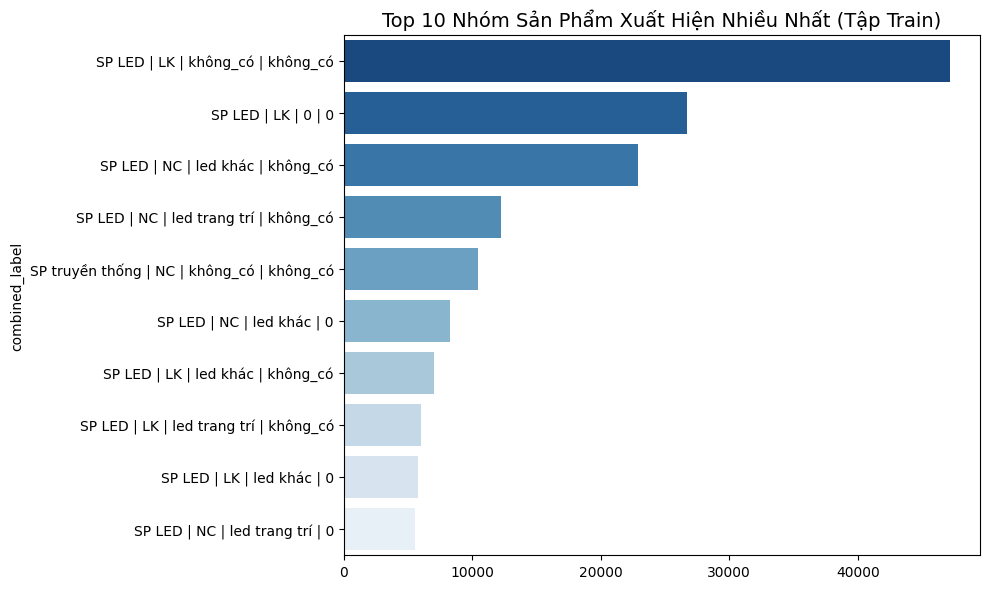

In [ ]:
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ\s]', ' ', text)
    return ' '.join(text.split()).strip()

df_train.fillna('', inplace=True)
df_train['text'] = "Hãng: " + df_train['Hãng'].astype(str) + " - Công suất: " + df_train['Công suất'].astype(str) + " - Sản phẩm: " + df_train['Tên hàng'].astype(str)
df_train['text'] = df_train['text'].apply(clean_text)
df_train = df_train[df_train['text'] != '']

# CẬP NHẬT: Thêm Lớp 2 vào dự đoán
cols_to_predict = ['Dòng SP', 'Loại', 'Lớp 1', 'Lớp 2']

for col in cols_to_predict:
    if col not in df_train.columns:
        df_train[col] = ''
    df_train[col] = df_train[col].astype(str).replace('', 'không_có')

# CẬP NHẬT: Ghép 4 cột thành Siêu nhãn (Super Label)
df_train['combined_label'] = (
    df_train['Dòng SP'] + " | " +
    df_train['Loại'] + " | " +
    df_train['Lớp 1'] + " | " +
    df_train['Lớp 2']
)

"""Lọc nhãn rác (xuất hiện dưới 5 lần)"""
label_counts = df_train['combined_label'].value_counts()
valid_labels = label_counts[label_counts >= 5].index
df_train = df_train[df_train['combined_label'].isin(valid_labels)]

"""Mã hóa nhãn"""
label_encoder = LabelEncoder()
df_train['label'] = label_encoder.fit_transform(df_train['combined_label'])
num_labels = len(label_encoder.classes_)
print(f"Tổng số nhãn phân loại: {num_labels}")

"""Chia tập dữ liệu chuẩn 80/10/10"""
train_df, temp_df = train_test_split(df_train[['text', 'label', 'Tên hàng', 'combined_label']], test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
test_df = test_df.copy()

print("--- KẾT QUẢ CHIA TẬP DATA ---")
print(f"Train: {len(train_df)} mẫu | Val: {len(val_df)} mẫu | Test: {len(test_df)} mẫu")

plt.figure(figsize=(10, 6))
top_labels = train_df['combined_label'].value_counts().head(10)
sns.barplot(x=top_labels.values, y=top_labels.index, palette='Blues_r')
plt.title('Top 10 Nhóm Sản Phẩm Xuất Hiện Nhiều Nhất (Tập Train)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
model_name = "vinai/phobert-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Thay đổi từ model_name thành MODEL_SAVE_PATH để tải mô hình của đồng nghiệp
model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_PATH, num_labels=num_labels, ignore_mismatched_sizes=True)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)
train_dataset = Dataset.from_pandas(train_df).map(tokenize_function, batched=True)
val_dataset = Dataset.from_pandas(val_df).map(tokenize_function, batched=True)
test_dataset = Dataset.from_pandas(test_df).map(tokenize_function, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

training_args = TrainingArguments(
    output_dir=CHECKPOINT_PATH,
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,
    report_to="none",
    warmup_ratio=0.1,
    lr_scheduler_type="cosine"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

print("--- BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN ---")
trainer.train()

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=46524, training_loss=0.857915156644615, metrics={'train_runtime': 6551.895, 'train_samples_per_second': 113.61, 'train_steps_per_second': 7.101, 'total_flos': 4.905045659181312e+16, 'train_loss': 0.857915156644615, 'epoch': 3.0})


--- TIẾN HÀNH THI CHỨNG CHỈ TRÊN TẬP TEST ĐỘC LẬP (10%) ---


ĐỘ CHÍNH XÁC THỰC TẾ TRÊN TẬP TEST: 76.13%



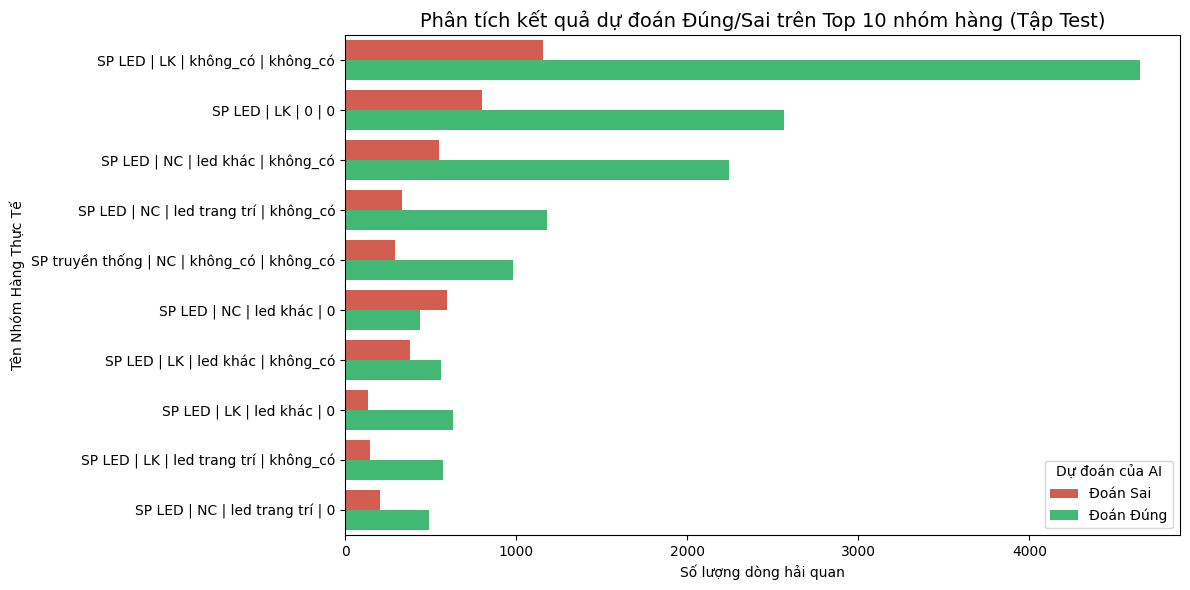

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
print("\n--- TIẾN HÀNH THI CHỨNG CHỈ TRÊN TẬP TEST ĐỘC LẬP (10%) ---")

test_results = trainer.predict(test_dataset)
test_preds = np.argmax(test_results.predictions, axis=-1)
test_labels = test_results.label_ids

test_acc = accuracy_score(test_labels, test_preds)
print(f"==========================================================")
print(f"ĐỘ CHÍNH XÁC THỰC TẾ TRÊN TẬP TEST: {test_acc * 100:.2f}%")
print(f"==========================================================\n")

"""Giải mã số thành nhãn chữ"""
test_df['predicted_label'] = label_encoder.inverse_transform(test_preds)
test_df['is_correct'] = test_df['combined_label'] == test_df['predicted_label']
top_test_labels = test_df['combined_label'].value_counts().head(10).index
test_df_top = test_df[test_df['combined_label'].isin(top_test_labels)].copy()

plt.figure(figsize=(12, 6))
sns.countplot(
    data=test_df_top,
    y='combined_label',
    hue='is_correct',
    order=top_test_labels,
    palette={True: '#2ecc71', False: '#e74c3c'}
)
plt.title('Phân tích kết quả dự đoán Đúng/Sai trên Top 10 nhóm hàng (Tập Test)', fontsize=14)
plt.xlabel('Số lượng dòng hải quan')
plt.ylabel('Tên Nhóm Hàng Thực Tế')
plt.legend(title='Dự đoán của AI', labels=['Đoán Sai', 'Đoán Đúng'])
plt.tight_layout()
plt.show()

THU_MUC_LUU_TRUC_TIEP = '/content/drive/MyDrive/CleanDatav2/working/'
trainer.save_model(THU_MUC_LUU_TRUC_TIEP)
with open(f"{THU_MUC_LUU_TRUC_TIEP}label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [5]:
import pandas as pd
import numpy as np

# ==========================================
# 1. ĐỌC FILE RAW XUẤT/NHẬP KHẨU
# ==========================================
INPUT_FILE_RAW = "/content/drive/MyDrive/CleanDatav2/datasets/file_xk_raw.csv"
OUTPUT_FILE_CLEAN = "/content/drive/MyDrive/CleanDatav2/datasets/file_xk_clean_mapped.csv"

print(f"Đang đọc dữ liệu từ {INPUT_FILE_RAW}...")
try:
    df_raw = pd.read_csv(INPUT_FILE_RAW, skiprows=9)
except Exception as e:
    print(f"Lỗi khi đọc file CSV: {e}")
    df_raw = pd.read_csv(INPUT_FILE_RAW)

df_clean = pd.DataFrame()

print("Đang map các cột dữ liệu trực tiếp...")
df_clean['Mã HS'] = df_raw['HS_Code']
df_clean['Dòng SP'] = df_raw['Product']
df_clean['Công ty XK'] = df_raw['VN_Exporter'].fillna(df_raw['VN_Exporter_EN'])
df_clean['Công ty NK'] = df_raw['Foreign_Importer']
df_clean['Quốc gia'] = df_raw['Destination_Country'].fillna(df_raw['Destination_Country_CN'])
df_clean['Châu lục'] = df_raw['Continent']
df_clean['Incoterms'] = df_raw['Incoterms']
df_clean['Method_of_Payment'] = df_raw['Method_of_Payment']
df_clean['DVT'] = df_raw['Unit_Qty']
df_clean['Lượng'] = df_raw['Quantity']
df_clean['Giá trị'] = df_raw['Total_Value_USD']
df_clean['Đơn giá'] = df_raw['Unit_Price_USD']

print("Đang xử lý các cột ghép...")
date_series = pd.to_datetime(df_raw['Date'], errors='coerce')
extracted_month = date_series.dt.month.astype(str)
month_from_month_col = df_raw['Month'].astype(str).str[-2:]
month_from_month_col = month_from_month_col.replace({'nan': np.nan, '': np.nan})

df_clean['Ngày'] = extracted_month.fillna(month_from_month_col)
df_clean['Ngày'] = pd.to_numeric(df_clean['Ngày'], errors='coerce').astype('Int64')
df_clean['Ngày'] = df_clean['Ngày'].apply(lambda x: f"Tháng {x}" if pd.notna(x) else '')

df_clean['Tên hàng'] = df_raw['Detailed_Product'].fillna(df_raw['Detailed_Product_EN']).fillna(df_raw['Detailed_Product_CN'])

df_clean['Loại'] = np.nan
df_clean['Lớp 1'] = np.nan
df_clean['Lớp 2'] = np.nan
df_clean['Công suất'] = np.nan
df_clean['Hãng'] = np.nan
df_clean['MDSD'] = np.nan
df_clean['Năm'] = np.nan

clean_columns_order = [
    'Ngày', 'Mã HS', 'Công ty NK', 'Tên hàng', 'DVT', 'Lượng', 'Giá trị',
    'Đơn giá', 'Hãng', 'Dòng SP', 'Loại', 'Lớp 1', 'Lớp 2', 'Công suất',
    'Quốc gia', 'Châu lục', 'MDSD', 'Công ty XK', 'Incoterms', 'Method_of_Payment', 'Năm'
]

df_clean = df_clean.reindex(columns=clean_columns_order)
df_clean.to_csv(OUTPUT_FILE_CLEAN, index=False, encoding='utf-8-sig')
print(f"Hoàn tất! File đã map thành công và lưu tại: {OUTPUT_FILE_CLEAN}")


Đang đọc dữ liệu từ /content/drive/MyDrive/CleanDatav2/datasets/file_xk_raw.csv...
Đang map các cột dữ liệu trực tiếp...
Đang xử lý các cột ghép...
Hoàn tất! File đã map thành công và lưu tại: /content/drive/MyDrive/CleanDatav2/datasets/file_xk_clean_mapped.csv


In [9]:
import torch
import torch.nn.functional as F
import pandas as pd
import re
import pickle
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN & NGƯỠNG
# ==========================================
LABEL_ENCODER_PATH = "/content/drive/MyDrive/CleanDatav2/working/label_encoder.pkl"
INPUT_FILE = "/content/drive/MyDrive/CleanDatav2/datasets/file_xk_clean_mapped.csv"
OUTPUT_FILE = "/content/drive/MyDrive/CleanDatav2/datasets/final_cleaned_file.csv"
DICT_FILE = "/content/drive/MyDrive/CleanDatav2/datasets/dictv3.csv"  # Đường dẫn bộ từ điển

THRESHOLD = 0.85  # Ngưỡng tự tin
DICT_THRESHOLD = 15 # Ngưỡng tự tin cho Từ điển (Chỉ duyệt khi có từ Chốt hạ hoặc cụm siêu dài)

HIGH_VALUE_KEYWORDS = [
    "năng lượng mặt trời", "nlmt", "bán nguyệt", "tuýp bán nguyệt", "âm trần", "đèn âm trần",
    "âm nước", "đèn âm nước", "mắt cáo", "rọi ray", "đèn rọi ray", "ống bơ", "ốp trần",
    "gắn tường", "đèn tường", "đội đầu", "đèn pin", "diệt côn trùng", "bắt muỗi",
    "ngoài trời", "cảnh quan", "sân vườn", "bảng hiệu", "soi bảng", "biển quảng cáo",
    "nhà xưởng", "nhà máy", "đánh cá", "câu mực", "bàn thờ", "trang trí",
    "thoát hiểm", "sự cố", "khẩn cấp", "panel", "đèn panel", "đèn chùm", "đèn thả",
    "dây led", "led cuộn", "thanh", "hồng ngoại", "cảm biến", "tuýp", "bulb", "tube",
    "bàn", "cực tím", "halogen", "cháy", "nổ", "dây", "uv", "hồng ngoại","phát quang",
    "UFO", "công nghiệp", "highbay", "lowbay", "flood", "pha", "downlight", "spotlight",
    "tracklight", "đường phố"
]

JUNK_KEYWORDS = [
    "chiếu sáng", "mới", "100", "hàng mới 100", "hàng mới", "hàng",
    "chính hãng", "chi tiết", "bộ phận", "công suất",
    "kích thước", "điện áp", "chất liệu", "nhôm", "nhựa", "hoạt động",
    "nsx", "co", "ltd", "industrial", "factory", "zhejiang", "zhongshan",
    "mới 100", "model", "dạng", "loại", "có", "led", "đèn led", "đèn"
]

# ==========================================
# 2. TẢI MÔ HÌNH VÀ CÔNG CỤ
# ==========================================
print("Đang nạp mô hình AI...")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")
model = AutoModelForSequenceClassification.from_pretrained('/content/drive/MyDrive/CleanDatav2/working/')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

with open(LABEL_ENCODER_PATH, 'rb') as f:
    label_encoder = pickle.load(f)

# ==========================================
# 3. TẢI BỘ TỪ ĐIỂN VÀ XÂY DỰNG MAPPING
# ==========================================
print("Đang nạp bộ từ điển...")
try:
    df_dict = pd.read_csv(DICT_FILE, encoding='utf-8-sig')
except:
    df_dict = pd.read_csv(DICT_FILE, encoding='latin1')

def clean_text_for_dict(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ\s]', ' ', text)
    return ' '.join(text.split()).strip()

dict_mapping = []
for _, row in df_dict.iterrows():
    kw_str = str(row.get('Keyword', '')).lower()
    keywords = [clean_text_for_dict(k) for k in kw_str.split(',') if clean_text_for_dict(k) != '']

    # Sắp xếp từ khoá từ dài xuống ngắn (theo độ dài chuỗi ký tự) để chạy thuật toán "Nuốt từ" tối ưu
    keywords.sort(key=lambda x: len(x), reverse=True)

    # Chuẩn hoá các trường nhãn từ từ điển
    d_sp = str(row.get('Dòng SP', 'không_có'))
    d_sp = d_sp if d_sp not in ['nan', 'None', '0', ''] else 'không_có'

    loai = str(row.get('Loại', 'không_có'))
    loai = loai if loai not in ['nan', 'None', '0', ''] else 'không_có'

    lop_1 = str(row.get('Lớp 1', 'không_có'))
    lop_1 = lop_1 if lop_1 not in ['nan', 'None', '0', ''] else 'không_có'

    lop_2 = str(row.get('Lớp 2', 'không_có'))
    lop_2 = lop_2 if lop_2 not in ['nan', 'None', '0', ''] else 'không_có'

    dict_mapping.append({
        'keywords': keywords,
        'label_str': f"{d_sp} | {loai} | {lop_1} | {lop_2}"
    })

# ==========================================
# 4. CÁC HÀM XỬ LÝ DỮ LIỆU CHÍNH
# ==========================================

def trich_xuat_thong_tin(raw_text):
    raw_text = str(raw_text)
    if '#&' in raw_text:
        parts = raw_text.split('#&')
        parts = [p.strip() for p in parts if p.strip()]
        if parts:
            raw_text = max(parts, key=len)

    raw_text_lower = raw_text.lower()
    cong_suat = ""
    match_w = re.search(r'(\d+(?:\.\d+)?)\s*(w|watt|hp|kw|kva|v)', raw_text_lower)
    if match_w:
        cong_suat = match_w.group(0).strip()

    hang = ""
    danh_sach_hang = ['rạng đông', 'điện quang', 'panasonic', 'philips', 'lg', 'samsung', 'daikin', 'sony', 'toshiba', 'sharp', 'sino', 'cadivi']
    for h in danh_sach_hang:
        if h in raw_text_lower:
            hang = h.capitalize()
            break
    return pd.Series([hang, cong_suat, raw_text])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ\s]', ' ', text)
    return ' '.join(text.split()).strip()

def predict_with_threshold(text):
    inputs = tokenizer(text, padding="max_length", truncation=True, max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = F.softmax(outputs.logits, dim=-1)
    max_prob, pred_id = torch.max(probabilities, dim=-1)

    confidence = max_prob.item()
    label = label_encoder.inverse_transform([pred_id.item()])[0]

    status = "Tự động duyệt (AI)" if confidence >= THRESHOLD else "Cần kiểm tra"
    return pd.Series([label, round(confidence * 100, 2), status])

def predict_hybrid(text):
    text_lower = clean_text_for_dict(text)

    best_mapping = None
    max_score = 0

    # 1. Chấm điểm toàn bộ Dictionary
    for mapping in dict_mapping:
        current_score = 0
        temp_text = text_lower  # Bản sao để thực hiện Nuốt từ (Masking)

        for kw in mapping['keywords']:
            pattern = r'\b' + re.escape(kw) + r'\b'
            if re.search(pattern, temp_text):
                # Kỹ thuật Nuốt từ (Consumption): xóa/che cụm từ đã khớp
                temp_text = re.sub(pattern, ' ', temp_text)

                # Tính điểm theo phân cấp (Scoring Weight)
                if any(hv in kw for hv in HIGH_VALUE_KEYWORDS):
                    current_score += 20  # Nhóm Chốt hạ
                elif any(kw == jk for jk in JUNK_KEYWORDS):
                    current_score += 0   # Từ rác (bị nuốt nhưng không được nhận điểm)
                else:
                    current_score += len(kw.split())  # Nhóm thường: nhận điểm theo chiếu dài n-gram

        if current_score > max_score:
            max_score = current_score
            best_mapping = mapping
        # Tie-breaker: Ưu tiên Nguyên Chiếc (NC) nếu điểm hòa với Linh Kiện (LK)
        elif current_score == max_score and current_score > 0 and best_mapping is not None:
            current_loai = mapping['label_str'].split(' | ')[1].strip().upper() if ' | ' in mapping['label_str'] else ''
            best_loai = best_mapping['label_str'].split(' | ')[1].strip().upper() if ' | ' in best_mapping['label_str'] else ''
            if current_loai == 'NC' and best_loai == 'LK':
                best_mapping = mapping

    # 2. Điều kiện ngưỡng: Tổng điểm khớp phải >= DICT_THRESHOLD
    if best_mapping is not None and max_score >= DICT_THRESHOLD:
        return pd.Series([best_mapping['label_str'], 100.0, f"Tự động duyệt (Từ điển - Điểm: {max_score})"])

    # 3. Fallback: Nếu không thoả mãn (score < DICT_THRESHOLD) thì gọi AI
    return predict_with_threshold(text)

# ==========================================
# 5. CHẠY TRÊN FILE DỮ LIỆU
# ==========================================
print(f"Đang đọc dữ liệu từ {INPUT_FILE}...")
df = pd.read_csv(INPUT_FILE)

print("Đang cắt bỏ nhiễu Hải quan (#&) và bóc tách Hãng, Công suất...")
df[['Hãng (Trích xuất)', 'Công suất', 'Tên hàng']] = df['Tên hàng'].apply(trich_xuat_thong_tin)

print("Đang chuẩn bị dữ liệu cho AI/Từ điển...")
df['input_for_ai'] = "Hãng: " + df['Hãng (Trích xuất)'] + " - Công suất: " + df['Công suất'] + " - Sản phẩm: " + df['Tên hàng'].astype(str).str.lower()
df['input_for_ai'] = df['input_for_ai'].apply(clean_text)

print("Đang tiến hành phân loại Hybrid (Kết hợp Từ Điển + AI ML)...")
df[['Ket_Qua_Gop', 'Độ Tự Tin (%)', 'Trạng Thái']] = df['input_for_ai'].apply(predict_hybrid)

print("Đang điền kết quả vào các cột Dòng SP, Loại, Lớp 1, Lớp 2...")
temp_cols = df['Ket_Qua_Gop'].str.split(r' \| ', expand=True)

for i in range(4):
    if i not in temp_cols.columns:
        temp_cols[i] = 'không_có'

df['Dòng SP'] = temp_cols[0]
df['Loại'] = temp_cols[1]
df['Lớp 1'] = temp_cols[2]
df['Lớp 2'] = temp_cols[3]

# Dọn dẹp các cột nháp không cần thiết
df = df.drop(columns=['input_for_ai', 'Ket_Qua_Gop'])
df = df.drop(columns=['Năm', 'Hãng (Trích xuất)'], errors='ignore')

# Xuất kết quả
df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
print(f"Hoàn tất! File kết quả phân loại Hybrid đã được lưu tại: {OUTPUT_FILE}")

Đang nạp mô hình AI...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Đang nạp bộ từ điển...
Đang đọc dữ liệu từ /content/drive/MyDrive/CleanDatav2/datasets/file_xk_clean_mapped.csv...
Đang cắt bỏ nhiễu Hải quan (#&) và bóc tách Hãng, Công suất...
Đang chuẩn bị dữ liệu cho AI/Từ điển...
Đang tiến hành phân loại Hybrid (Kết hợp Từ Điển + AI ML)...
Đang điền kết quả vào các cột Dòng SP, Loại, Lớp 1, Lớp 2...
Hoàn tất! File kết quả phân loại Hybrid đã được lưu tại: /content/drive/MyDrive/CleanDatav2/datasets/final_cleaned_file.csv
